## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)

! pip install ucimlrepo

In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [3]:
X.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


In [4]:
#check dimensions
print(X.shape)
print(y.shape)

(517, 12)
(517, 1)


In [5]:
#handling missing or incorrect data
X.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64

In [6]:
y.isnull().sum()

area    0
dtype: int64

Interpretation : The dataset contains no missing values, therefore no imputation was required.

The Forest Fires dataset was successfully loaded from the UCI Machine Learning Repository. The dataset contains environmental, weather, and geographic predictors used to estimate wildfire damage. The target variable is area, representing the burned area of the forest in hectares. Initial inspection showed that the dataset contains 517 observations and 12 predictor variables. No missing values were identified, meaning the dataset was suitable for further exploratory analysis and modeling.

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [7]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

In [8]:
# Combine features and target into one dataframe
df = pd.concat([X, y], axis=1)
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


The predictors and target variable were combined into one dataframe to make the exploratory analysis easier. The dataset contains environmental, weather, and geographic factors used to analyze forest fire behavior.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [10]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


Initial exploration shows that the dataset contains numerical weather measurements, fire indexes, and categorical variables such as month and day. The target variable (area) shows a large difference between the minimum and maximum values, suggesting that burned area is highly skewed because most fires are small, while a few fires are extremely large.

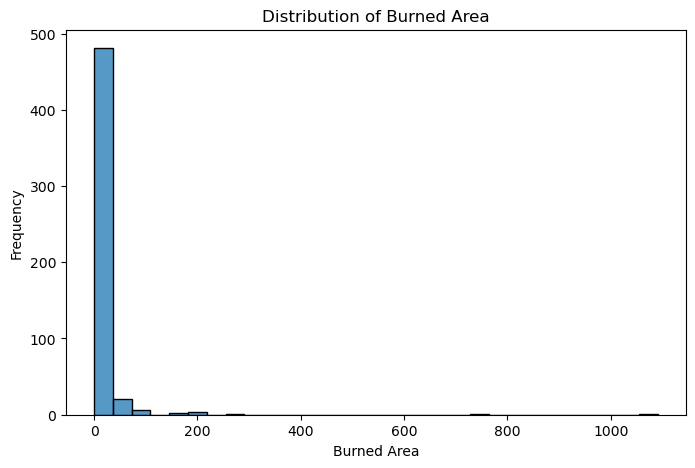

In [11]:
# Distribution of burned area
plt.figure(figsize=(8,5))

sns.histplot(df['area'], bins=30)

plt.title("Distribution of Burned Area")
plt.xlabel("Burned Area")
plt.ylabel("Frequency")

plt.show()

The distribution of burned area is highly right-skewed. Most forest fires resulted in little or no burned area, while a small number of fires caused significantly larger damage. A logarithmic transformation may improve regression modeling.

In [12]:
# Create transformed target variable
df['log_area'] = np.log1p(df['area'])

# Display records where burned area is greater than zero
df[df['area'] > 0][['area', 'log_area']].head()

,area,log_area
138,0.36,0.307485
139,0.43,0.357674
140,0.47,0.385262
141,0.55,0.438255
142,0.61,0.476234


##### Log Transformation of Burned Area
The burned area variable is highly right-skewed because most fires have little or no recorded burned area, while a few fires cause very large damage.

A log transformation was applied using log1p() to reduce skewness and limit the effect of extreme values. The log1p method was selected because the area variable contains zero values.

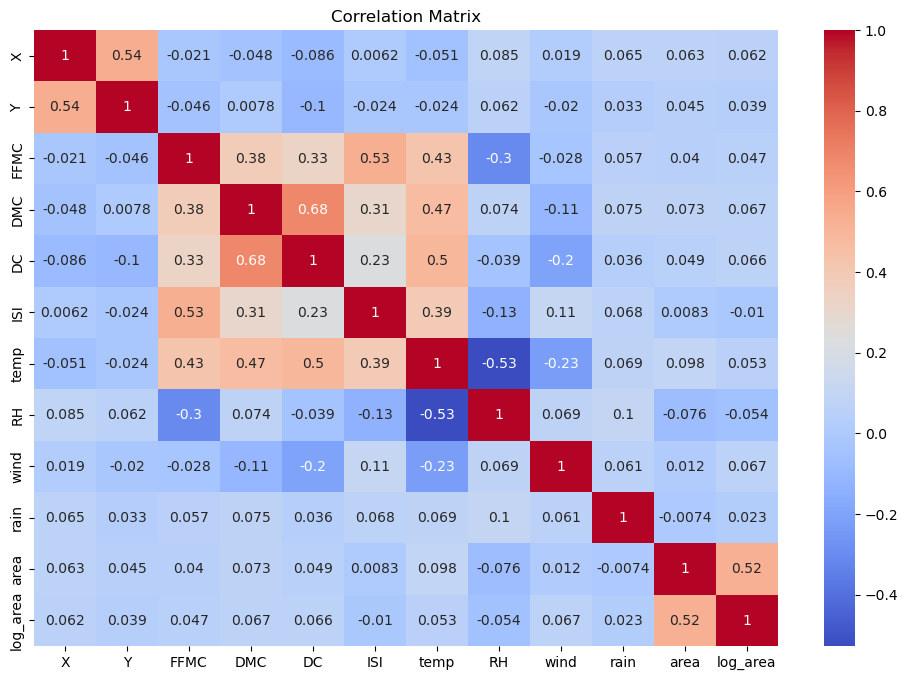

In [13]:
# Correlation matrix
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [14]:
# Correlation with burned area
correlation['area'].sort_values(ascending=False)

area        1.000000
log_area    0.524134
temp        0.097844
DMC         0.072994
X           0.063385
DC          0.049383
Y           0.044873
FFMC        0.040122
wind        0.012317
ISI         0.008258
rain       -0.007366
RH         -0.075519
Name: area, dtype: float64

Correlation analysis was used to identify relationships between predictors and burned area. Weather variables such as temperature, humidity, wind, and fire weather indexes were examined to determine their influence on fire severity.

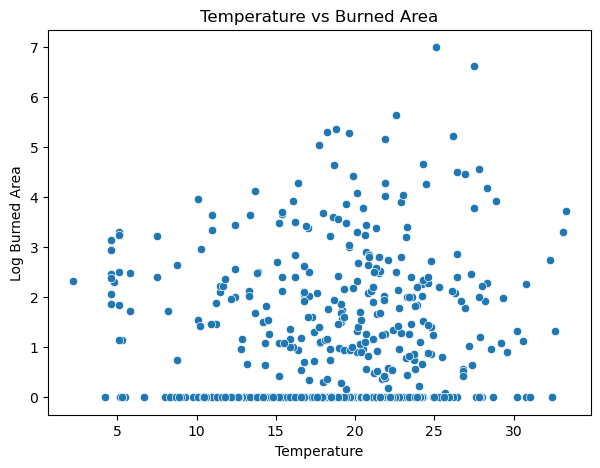

In [15]:
# Temperature vs Fire Area
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='temp',
    y='log_area'
)

plt.title("Temperature vs Burned Area")
plt.xlabel("Temperature")
plt.ylabel("Log Burned Area")

plt.show()

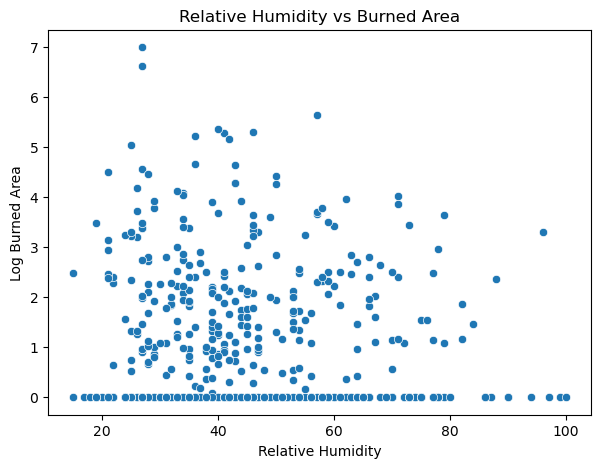

In [16]:
# Humidity vs Firea Area
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='RH',
    y='log_area'
)

plt.title("Relative Humidity vs Burned Area")
plt.xlabel("Relative Humidity")
plt.ylabel("Log Burned Area")

plt.show()

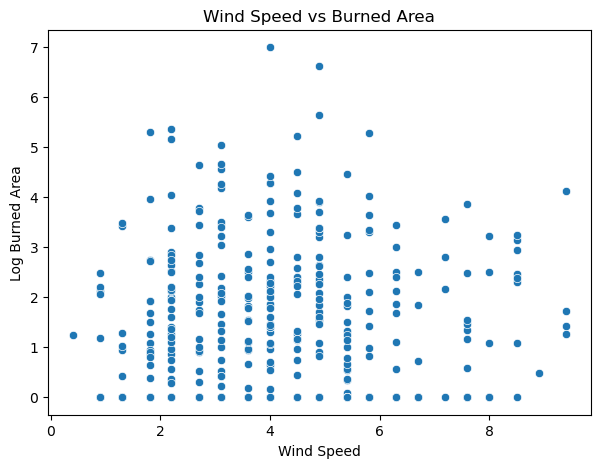

In [17]:
# Wind vs Fire Area
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='wind',
    y='log_area'
)

plt.title("Wind Speed vs Burned Area")
plt.xlabel("Wind Speed")
plt.ylabel("Log Burned Area")

plt.show()

The scatterplots show that individual predictors do not have a strong linear relationship with burned area. This suggests that forest fire severity is influenced by multiple interacting environmental factors rather than a single variable.

In [18]:
# Residual Plot
from sklearn.linear_model import LinearRegression

# Select predictors
features = ['temp','RH','wind','rain']

X_simple = df[features]
y_simple = df['log_area']

# Train model
linear_model = LinearRegression()
linear_model.fit(X_simple, y_simple)

predictions = linear_model.predict(X_simple)

residuals = y_simple - predictions

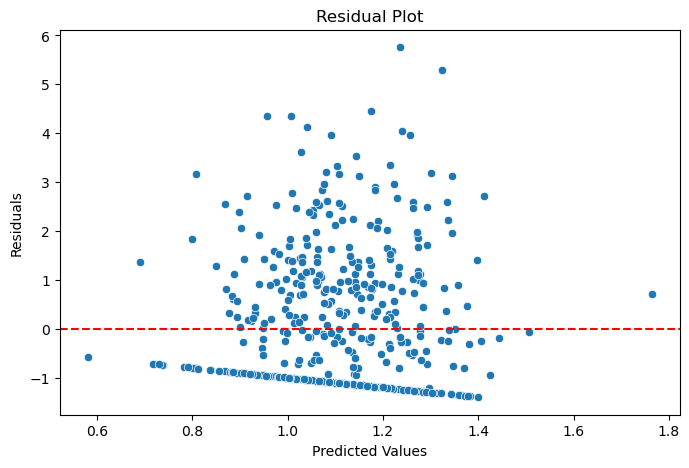

In [19]:
# Plotting residuals
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

The residual plot has been used to evaluate whether model errors were randomly distributed. Randomly scattered residuals around zero suggest that the linear regression assumptions are reasonable, while clear patterns would indicate possible non-linearity or missing predictors.

Summary: 
Exploratory analysis showed that the forest fire dataset contains complete records with no missing values. The burned area variable was highly skewed, requiring a logarithmic transformation before modeling. Correlation and scatterplot analysis showed weak individual relationships between predictors and fire size, suggesting that wildfire behavior depends on multiple environmental factors. An initial residual analysis was performed to assess suitability for regression modeling.

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

#### Regression Model Development

Multiple regression models were developed to predict the burned forest area. Since the original area variable was highly skewed, the transformed log_area variable was used as the target variable.

Different model improvements were tested including nonlinear transformations, interaction terms, and categorical indicator variables.

In [20]:
# Select numerical predictors for baseline model
regression_features = [
    'temp',
    'RH',
    'wind',
    'rain',
    'FFMC',
    'DMC',
    'DC',
    'ISI'
]
X_reg = df[regression_features]

# Target variable
y_reg = df['log_area']

A baseline model was created using weather variables and fire index measurements because these factors directly influence wildfire occurrence and spread.

In [21]:
# Add constant term
X_baseline = sm.add_constant(X_reg)

# Fit baseline regression model
baseline_model = sm.OLS(
    y_reg,
    X_baseline
).fit()

# Display results
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.288
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.247
Time:                        14:43:23   Log-Likelihood:                -901.28
No. Observations:                 517   AIC:                             1821.
Df Residuals:                     508   BIC:                             1859.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2224      1.360      0.163      0.8

#### Baseline Multiple Linear Regression Interpretation
The baseline multiple linear regression model was developed using environmental and fire weather predictors to estimate log-transformed burned area.

The model produced an R-squared value of 0.020, meaning that approximately 2% of the variation in burned area was explained by the selected predictors. This indicates weak predictive performance, suggesting that wildfire severity is influenced by additional factors not captured by the model.

Among the predictors, wind speed was statistically significant (p < 0.05), indicating that increased wind speed is associated with larger burned areas. Other variables such as temperature, humidity, rainfall, and fire weather indexes did not show statistically significant effects in this baseline model.

The high condition number suggests possible multicollinearity among predictors, particularly among fire weather index variables. Regularization techniques such as Ridge and Lasso regression will be applied later to address this issue.

In [22]:
# Add quadratic temperature feature
df['temp_squared'] = df['temp'] ** 2

In [23]:
# Add nonlinear term
X_quad = df[
    [
        'temp',
        'temp_squared',
        'RH',
        'wind',
        'rain',
        'FFMC',
        'DMC',
        'DC',
        'ISI'
    ]
]
X_quad = sm.add_constant(X_quad)
quadratic_model = sm.OLS(
    y_reg,
    X_quad
).fit()

print(quadratic_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     2.338
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0138
Time:                        14:43:23   Log-Likelihood:                -895.96
No. Observations:                 517   AIC:                             1812.
Df Residuals:                     507   BIC:                             1854.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7710      1.358      0.568   

A quadratic temperature term was added to capture possible nonlinear relationships between temperature and burned area because fire behavior may change more rapidly at higher temperatures.

##### Quadratic Regression Model Interpretation
A quadratic temperature term was added to capture nonlinear relationships between temperature and burned area.

Compared with the baseline model, the quadratic model improved performance, increasing R-squared from 0.020 to 0.040 and reducing AIC from 1821 to 1812.

Both temperature and the squared temperature term were statistically significant (p < 0.05), indicating that temperature has a nonlinear relationship with wildfire severity.

Although the improvement was small, the quadratic model captured additional variation in burned area compared to the baseline regression model.

In [24]:
# Create interaction feature
df['temp_RH_interaction'] = df['temp'] * df['RH']

In [25]:
# Regression model with interaction term
X_interaction = df[
    [
        'temp',
        'temp_squared',
        'RH',
        'temp_RH_interaction',
        'wind',
        'rain',
        'FFMC',
        'DMC',
        'DC',
        'ISI'
    ]
]
X_interaction = sm.add_constant(X_interaction)
interaction_model = sm.OLS(
    y_reg,
    X_interaction
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     2.372
Date:                Thu, 11 Jun 2026   Prob (F-statistic):            0.00949
Time:                        14:43:23   Log-Likelihood:                -894.63
No. Observations:                 517   AIC:                             1811.
Df Residuals:                     506   BIC:                             1858.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.4926    

An interaction term between temperature and relative humidity was added because the effect of temperature on fire severity may depend on moisture conditions.

##### Interaction Regression Model Interpretation
An interaction term between temperature and relative humidity was introduced because wildfire behavior may depend on combined weather conditions rather than individual variables.

The interaction model slightly improved performance, increasing R-squared from 0.040 to 0.045 and decreasing AIC from 1812 to 1811.

However, the temperature-humidity interaction term was not statistically significant (p > 0.05), suggesting limited evidence that this interaction strongly influences burned area in this dataset.

The model still shows possible multicollinearity based on the high condition number, which will be addressed later using Ridge and Lasso regularization.

In [26]:
# Convert categorical variables into dummy variables
df_encoded = pd.get_dummies(
    df,
    columns = ['month','day'],
    drop_first = True,
    dtype = int
)

In [27]:
# Select predictors including dummy variables
X_final = df_encoded.drop(
    columns=[
        'area',
        'log_area'
    ]
)
y_final = df_encoded['log_area']

# Add constant
# Convert all columns to numeric format
X_final = X_final.astype(float)
X_final = sm.add_constant(X_final)

In [28]:
# Final regression model
final_model = sm.OLS(
    y_final,
    X_final
).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     1.579
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0297
Time:                        14:43:24   Log-Likelihood:                -883.24
No. Observations:                 517   AIC:                             1826.
Df Residuals:                     487   BIC:                             1954.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.9572    

Categorical variables were converted into indicator variables to allow month and day information to be included in the regression model.

Several regression models were developed to predict the forest fire burned area. The baseline model used environmental predictors, while additional models introduced a quadratic temperature term, interaction effects, and categorical indicator variables.

The log-transformed burned area was used to reduce skewness and improve model reliability. These models will be compared using performance metrics and diagnostic checks in the next stage.

#### Final Regression Model Interpretation
The final regression model included environmental predictors, nonlinear temperature effects, interaction terms, and categorical indicator variables for month and day.

The model achieved an R-squared value of 0.086, meaning approximately 8.6% of the variation in burned area was explained by the predictors. This was higher than the previous regression models, showing that adding nonlinear terms and categorical variables improved model fit.

The overall model was statistically significant based on the F-test (p < 0.05). DMC, temperature, and the quadratic temperature term were significant predictors of burned area.

The categorical month and day variables did not individually show strong statistical significance, suggesting limited evidence that specific time categories strongly influenced burned area in this dataset.

The high condition number indicates possible multicollinearity among predictors. Ridge and Lasso regression will be applied later to improve generalization and handle correlated features.

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

Regression models were evaluated using goodness-of-fit metrics and diagnostic checks. R-squared, adjusted R-squared, AIC, and BIC were compared to determine model performance. Residual analysis, Q-Q plots, and Cook's Distance were used to assess model assumptions and identify influential observations.

In [29]:
# Compare regression model performance
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline Model',
        'Quadratic Model',
        'Interaction Model',
        'Final Model'
    ],
    
    'R_squared': [
        baseline_model.rsquared,
        quadratic_model.rsquared,
        interaction_model.rsquared,
        final_model.rsquared
    ],
    
    'Adjusted_R_squared': [
        baseline_model.rsquared_adj,
        quadratic_model.rsquared_adj,
        interaction_model.rsquared_adj,
        final_model.rsquared_adj
    ],
    
    'AIC': [
        baseline_model.aic,
        quadratic_model.aic,
        interaction_model.aic,
        final_model.aic
    ],
    
    'BIC': [
        baseline_model.bic,
        quadratic_model.bic,
        interaction_model.bic,
        final_model.bic
    ]
})

model_comparison

,Model,R_squared,Adjusted_R_squared,AIC,BIC
0,Baseline Model,0.019881,0.004446,1820.555830,1858.788216
1,Quadratic Model,0.039853,0.022809,1811.912210,1854.392639
2,Interaction Model,0.044773,0.025895,1811.256042,1857.984514
3,Final Model,0.085944,0.031514,1826.478498,1953.919784


##### Model Comparison Interpretation
The final regression model achieved the highest R-squared value, meaning it explained the largest proportion of variation in burned area.

However, the interaction model achieved the lowest AIC value, suggesting a better balance between model performance and complexity.

Although adding indicator variables increased R-squared, the increase in AIC and BIC suggests that the additional variables added complexity without greatly improving prediction performance.

In [30]:
# Calculate fitted values and residuals
fitted_values = final_model.fittedvalues

residuals = final_model.resid

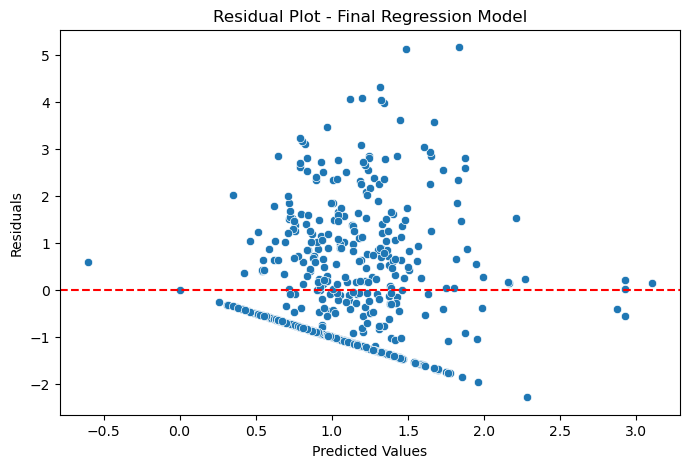

In [31]:
# Residual plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot - Final Regression Model")

plt.show()

##### Residual Plot Interpretation
The residual plot was used to check whether prediction errors were randomly distributed. Ideally, residuals should be scattered around zero without a clear pattern.

The presence of some spread indicates that the model does not capture all variation in burned area, suggesting that wildfire severity is influenced by additional factors.

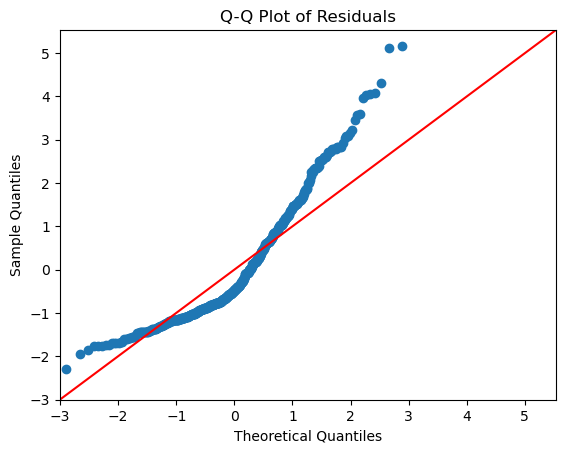

In [32]:
# Q-Q plot
sm.qqplot(
    residuals,
    line='45'
)

plt.title(
    "Q-Q Plot of Residuals"
)

plt.show()

##### Q-Q Plot Interpretation
The Q-Q plot was used to assess whether residuals follow a normal distribution.

Points close to the diagonal line indicate normally distributed residuals. Deviations from the line suggest that some non-normality remains, which is expected due to the unpredictable nature of wildfire data.

In [33]:
# Calculate Cook's Distance
influence = final_model.get_influence()

cooks_distance = influence.cooks_distance[0]

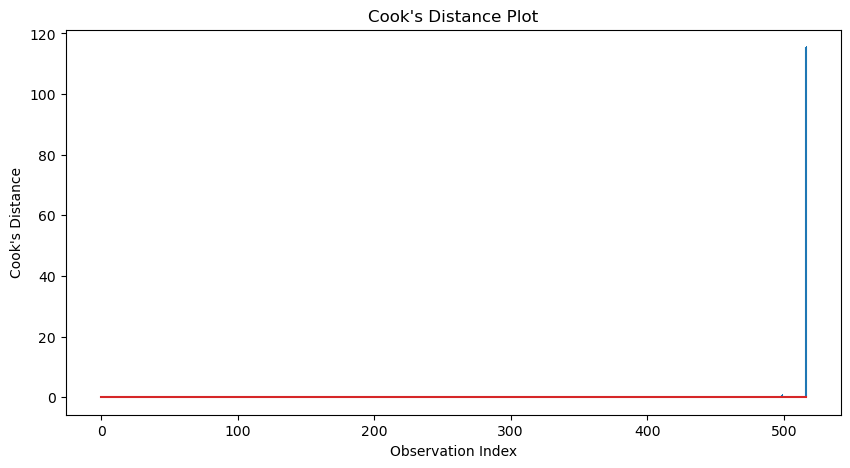

In [34]:
# Plot Cook's Distance
plt.figure(figsize=(10,5))

plt.stem(
    np.arange(len(cooks_distance)),
    cooks_distance,
    markerfmt=","
)

plt.xlabel("Observation Index")

plt.ylabel("Cook's Distance")

plt.title("Cook's Distance Plot")

plt.show()

In [35]:
# Top influential observations
top_influential = np.argsort(cooks_distance)[-5:]

top_influential

array([104, 471, 304, 499, 516])

##### Cook's Distance Interpretation
Cook's Distance identified observations 104, 471, 304, 499, and 516 as the most influential data points in the regression model.

These observations have a stronger effect on the fitted regression line compared with other records. In the context of forest fires, influential observations are expected because wildfire data contains rare extreme events with unusually large burned areas.

The observations were retained because they represent real wildfire behavior rather than data entry errors.

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

Regularization techniques were applied to reduce the impact of multicollinearity and improve model generalization.

Ridge Regression (L2) reduces the size of coefficients but keeps all predictors, while Lasso Regression (L1) can shrink less important predictor coefficients to zero, performing feature selection.

In [36]:
# Import regularization libraries

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [37]:
# Prepare features and target
X_regularized = df_encoded.drop(
    columns=[
        'area',
        'log_area'
    ]
)
y_regularized = df_encoded['log_area']

In [38]:
# Convert predictors to numeric values
X_regularized = X_regularized.astype(float)

In [39]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_regularized,
    y_regularized,
    test_size=0.2,
    random_state=42
)

In [40]:
# Standardize predictor variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [41]:
# Apply Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [42]:
# Ridge predictions
ridge_predictions = ridge_model.predict(
    X_test_scaled
)

In [43]:
# Ridge Mean Squared Error
ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_mse

2.269066480877552

In [44]:
# Apply Lasso Regression
lasso_model = Lasso(
    alpha=0.01
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [45]:
# Lasso predictions
lasso_predictions = lasso_model.predict(
    X_test_scaled
)

In [46]:
# Lasso Mean Squared Error
lasso_mse = mean_squared_error(
    y_test,
    lasso_predictions
)

lasso_mse

2.2334582523408164

In [47]:
# Compare coefficients

coefficients = pd.DataFrame({
    'Feature': X_regularized.columns,
    
    'Ridge_Coefficient': ridge_model.coef_,
    
    'Lasso_Coefficient': lasso_model.coef_  
})

coefficients

,Feature,Ridge_Coefficient,Lasso_Coefficient
0,X,0.127147,0.113883
1,Y,-0.002550,0.000000
2,FFMC,0.100938,0.054149
3,DMC,0.303309,0.197175
4,DC,-0.434275,-0.055333
5,ISI,-0.080210,-0.035179
6,temp,-0.945321,-0.000000
7,RH,-0.256355,0.001181
8,wind,0.045802,0.033948
9,rain,-0.003058,0.011614


##### Ridge and Lasso Coefficient Interpretation
Ridge and Lasso regression were applied to handle multicollinearity among predictors.

Ridge regression reduced the magnitude of the coefficients while retaining all predictor variables. This allowed the model to keep information from all environmental, geographic, and temporal features.

Lasso regression performed feature selection by shrinking some coefficients completely to zero. Variables such as Y location, temperature, temperature-humidity interaction, and some month indicators were removed, suggesting they contributed less predictive value.

Important predictors retained by the regularized models included DMC, temperature squared, month indicators, and geographic location variables. These results suggest that drought conditions, nonlinear temperature effects, seasonal factors, and location may influence wildfire severity.

In [48]:
# Compare model performance
regularization_results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MSE': [
        ridge_mse,
        lasso_mse
    ]
})

regularization_results

,Model,MSE
0,Ridge Regression,2.269066
1,Lasso Regression,2.233458


##### Ridge and Lasso Model Performance Comparison
The Ridge regression model achieved a Mean Squared Error (MSE) of 2.269, while the Lasso regression model achieved a slightly lower MSE of 2.233.

Since a lower MSE indicates better predictive performance, Lasso regression performed slightly better than Ridge regression on the test data.

Ridge retained all predictor variables while reducing coefficient sizes, whereas Lasso performed feature selection by shrinking some less important coefficients to zero.

The results suggest that removing weaker predictors helped improve model performance slightly, making Lasso the preferred regularized model for this dataset.

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

The regression problem was converted into a classification problem by transforming the continuous burned area variable into a binary target variable.

A threshold was applied to classify fires as either low-risk or high-risk. Predictor variables were selected and standardized before training the classification model.

In [49]:
# Calculate median burned area
df['area'].median()

0.52

In [50]:
# Create binary fire risk variable
df['high_risk'] = np.where(
    df['area'] > df['area'].median(),
    1,
    0
)

# Check class distribution
df['high_risk'].value_counts()

high_risk
0    259
1    258
Name: count, dtype: int64

##### Binary Target Distribution Interpretation
The burned area variable was converted into a binary classification target using the median as the threshold.

The resulting classes were almost evenly distributed, with 259 low-risk fires and 258 high-risk fires. This balanced distribution helps prevent model bias toward one class during logistic regression training.

The balanced target variable is suitable for developing a wildfire risk classification model.

In [51]:
# Select predictors for classification
classification_features = [
    'temp',
    'RH',
    'wind',
    'rain',
    'FFMC',
    'DMC',
    'DC',
    'ISI'
]

X_classification = df[classification_features]

y_classification = df['high_risk']

In [52]:
X_classification.head()

,temp,RH,wind,rain,FFMC,DMC,DC,ISI
0,8.2,51,6.7,0.0,86.2,26.2,94.3,5.1
1,18.0,33,0.9,0.0,90.6,35.4,669.1,6.7
2,14.6,33,1.3,0.0,90.6,43.7,686.9,6.7
3,8.3,97,4.0,0.2,91.7,33.3,77.5,9.0
4,11.4,99,1.8,0.0,89.3,51.3,102.2,9.6


##### Predictor Selection
Environmental and fire weather variables were selected as predictors because they directly relate to wildfire conditions and fire spread potential.

In [53]:
# Import train test split
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42
)

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
# Scale classification predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_class
)

X_test_scaled = scaler.transform(
    X_test_class
)

In [56]:
# Check final training and testing shapes
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(413, 8)
(104, 8)


##### Feature Scaling
StandardScaler was applied to standardize predictor variables by giving them a mean of 0 and standard deviation of 1.

Scaling was necessary because predictors such as temperature, wind speed, and fire index measurements have different value ranges, which can affect logistic regression performance.

##### Classification Preparation Summary
The dataset was successfully transformed from a regression problem into a binary classification problem.

A high-risk target variable was created based on burned area, relevant environmental predictors were selected, and the features were standardized using StandardScaler.

The prepared data will be used to train and evaluate a logistic regression model.

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

A logistic regression model was trained using the scaled environmental predictors to classify fires as either low-risk or high-risk.

The model performance was evaluated using accuracy, confusion matrix, precision, recall, and F1-score.

In [57]:
# Import logistic regression and classification metrics
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [58]:
# Create logistic regression model
logistic_model = LogisticRegression()

# Train model
logistic_model.fit(
    X_train_scaled,
    y_train_class
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
# Display model coefficients
logistic_coefficients = pd.DataFrame({
    'Feature': classification_features,
    
    'Coefficient': logistic_model.coef_[0]
})

logistic_coefficients

,Feature,Coefficient
0,temp,0.069411
1,RH,0.001769
2,wind,0.189251
3,rain,0.048558
4,FFMC,0.267018
5,DMC,0.005548
6,DC,0.113295
7,ISI,-0.199661


In [60]:
# Display intercept
logistic_model.intercept_

array([-7.87877612e-05])

##### Logistic Regression Coefficient Interpretation
The logistic regression coefficients show how each predictor affects the likelihood of a fire being classified as high-risk.

Positive coefficients increase the probability of a high-risk classification, while negative coefficients decrease the probability.

The strongest positive predictors were FFMC, wind speed, and DC, suggesting that fuel dryness, wind conditions, and drought-related factors contribute to increased wildfire risk.

The intercept value was close to zero, indicating that when standardized predictor values are average, the baseline classification tendency is approximately balanced.

In [61]:
# Predict probabilities
y_probabilities = logistic_model.predict_proba(
    X_test_scaled
)

y_probabilities[:5]

array([[0.54298195, 0.45701805],
       [0.43148363, 0.56851637],
       [0.49886809, 0.50113191],
       [0.50659972, 0.49340028],
       [0.52925517, 0.47074483]])

##### Probability Prediction Interpretation
The logistic regression model generated probabilities for each fire risk category.

The first probability represents the likelihood of a fire being classified as low-risk (0), while the second probability represents the likelihood of a fire being classified as high-risk (1).

The final classification is determined by selecting the category with the higher predicted probability.

In [62]:
# Predict binary classes
y_predictions = logistic_model.predict(
    X_test_scaled
)

y_predictions[:10]

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 0])

##### Binary Prediction Interpretation
The trained logistic regression model converted predicted probabilities into final fire risk classifications.

A prediction value of 0 represents a low-risk fire, while a prediction value of 1 represents a high-risk fire.

These predicted classes were compared against the actual test labels to evaluate classification performance.

In [63]:
# Calculate accuracy
accuracy = accuracy_score(
    y_test_class,
    y_predictions
)

accuracy

0.4519230769230769

In [64]:
# Confusion matrix
conf_matrix = confusion_matrix(
    y_test_class,
    y_predictions
)

conf_matrix

array([[24, 29],
       [28, 23]])

In [65]:
# Calculate evaluation metrics
precision = precision_score(
    y_test_class,
    y_predictions
)

recall = recall_score(
    y_test_class,
    y_predictions
)

f1 = f1_score(
    y_test_class,
    y_predictions
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.4423076923076923
Recall: 0.45098039215686275
F1-score: 0.44660194174757284


##### Logistic Regression Model Evaluation Interpretation
The logistic regression model achieved an accuracy score of 45.2%, meaning that the model correctly classified approximately 45% of fires as either low-risk or high-risk.

The confusion matrix showed that the model correctly identified 24 low-risk fires and 23 high-risk fires. However, it also produced several incorrect classifications, indicating difficulty separating the two risk groups.

The precision score of 0.442 shows that approximately 44% of predicted high-risk fires were actually high-risk. The recall score of 0.451 indicates that the model detected about 45% of actual high-risk fires.

The F1-score of 0.447 reflects the balance between precision and recall. Overall, the logistic regression model provides a simple and interpretable classification approach, but the results suggest that wildfire risk prediction is challenging and may require additional features or more complex models for improved performance.

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

Variance Inflation Factor (VIF) was used to evaluate multicollinearity among predictor variables.

Multicollinearity occurs when independent variables are highly correlated with each other, which can make regression coefficients unstable and difficult to interpret.

In [66]:
# Import VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [67]:
# Prepare predictor variables for VIF
X_vif = df_encoded.drop(
    columns=[
        'area',
        'log_area'
    ]
)

# Ensure all values are numeric
X_vif = X_vif.astype(float)

In [68]:
# Calculate VIF values
vif_results = pd.DataFrame()

vif_results['Feature'] = X_vif.columns
vif_results['VIF'] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(
        X_vif.shape[1]
    )
]

vif_results

,Feature,VIF
0,X,7.728534
1,Y,20.045017
2,FFMC,307.402183
3,DMC,14.877836
4,DC,154.982051
5,ISI,8.420132
6,temp,911.862429
7,RH,83.769226
8,wind,7.480324
9,rain,1.171820


In [69]:
# Sort VIF values
vif_results.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
6,temp,911.862429
2,FFMC,307.402183
10,temp_squared,188.512786
4,DC,154.982051
11,temp_RH_interaction,107.746624
7,RH,83.769226
22,month_sep,79.546772
12,month_aug,67.701341
1,Y,20.045017
3,DMC,14.877836


##### Variance Inflation Factor (VIF) Interpretation
The VIF analysis was performed to assess multicollinearity among the predictor variables.

Several predictors showed high levels of multicollinearity, with VIF values greater than 10. The highest values were observed for temperature (VIF = 911.86), FFMC (VIF = 307.40), temperature squared (VIF = 188.51), DC (VIF = 154.98), and the temperature-humidity interaction term (VIF = 107.75).

The high VIF values for temperature-related variables are expected because the quadratic and interaction features were created from the original temperature variable. Similarly, fire weather indicators such as FFMC, DMC, DC, and ISI contain related environmental information, causing correlation between predictors.

Some predictors, including rainfall and day indicators, showed low VIF values, indicating little multicollinearity.

The presence of multicollinearity supports the earlier use of Ridge and Lasso regression. These regularization techniques help improve model stability by reducing the effect of highly correlated predictors.

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

#### Regression Model Comparison
Several regression models were developed to predict the burned area caused by forest fires.

The baseline multiple linear regression model had limited predictive ability, achieving an R-squared value of 0.020. This indicated that the initial environmental predictors explained only a small percentage of the variation in burned area.

Adding a quadratic temperature term improved model performance, increasing R-squared to 0.040. The temperature and temperature squared variables were statistically significant, showing that temperature has a nonlinear relationship with wildfire severity.

The interaction model, which included a temperature and relative humidity interaction term, further increased R-squared to 0.045. However, the interaction effect itself was not statistically significant, suggesting limited additional predictive value.

The final regression model, which included nonlinear features, interaction terms, and categorical indicator variables for month and day, achieved the highest R-squared value of 0.086. However, the increase in model complexity resulted in higher AIC and BIC values, showing a trade-off between predictive performance and simplicity.

##### Regularization Results
Variance Inflation Factor analysis identified strong multicollinearity among predictors, especially temperature-related variables and fire weather indicators such as FFMC, DMC, and DC.

Ridge and Lasso regression were applied to reduce the impact of multicollinearity.

Ridge regression retained all predictor variables while reducing coefficient sizes and achieved an MSE of 2.269.

Lasso regression performed feature selection by shrinking less important coefficients to zero and achieved a slightly lower MSE of 2.233.

Based on the lower MSE and simpler feature selection approach, Lasso regression performed slightly better and provided a more interpretable model.

##### Classification Model Findings
The regression problem was converted into a binary classification problem by categorizing fires as low-risk or high-risk based on the median burned area.

The logistic regression model achieved:
- Accuracy: 45.2%
- Precision: 44.2%
- Recall: 45.1%
- F1-score: 44.7%

The classification results showed that predicting wildfire risk is challenging because fire behavior is influenced by complex environmental interactions.

Important predictors identified by the logistic regression model included FFMC, wind speed, and DC, suggesting that fuel dryness, wind conditions, and drought-related factors contribute to wildfire risk.

##### Final Recommendation
For predicting the actual burned area of forest fires, Lasso regression is recommended because it achieved the lowest Mean Squared Error while reducing unnecessary predictors. This provides a better balance between prediction performance, simplicity, and interpretability.

For classifying fires into high-risk and low-risk categories, logistic regression provides a simple and interpretable approach, but its moderate performance suggests that more advanced models or additional environmental data may be needed for more accurate wildfire classification.

Overall, the analysis shows that wildfire severity is influenced by a combination of environmental conditions rather than a single factor. Forestry management teams should pay close attention to drought indicators, fuel moisture conditions, temperature patterns, and wind speed when planning fire prevention strategies.